# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados são obtidos diretamente da API pública de **Carga Verificada** do **Operador Nacional do Sistema Elétrico (ONS)**.

> **Importante:** este notebook precisa ser executado em um ambiente com acesso à internet (Google Colab ou Jupyter local), pois as células de consulta à API do ONS e, opcionalmente, à API do Gemini, dependem de conexão externa.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Área analisada: **SP — São Paulo**, período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para exibir DataFrames formatados também fora do Jupyter clássico
from IPython.display import display

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [6]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [7]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [8]:
type(registros)

list

In [9]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [10]:
# DESAFIO 1 — Construção e inspeção do DataFrame

dados = pd.DataFrame(registros)

print("Primeiras linhas do DataFrame:")
display(dados.head())

print(f"\nQuantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")

print("\nNomes dos atributos (colunas):")
print(list(dados.columns))

Primeiras linhas do DataFrame:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos (colunas):
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [11]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [12]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


**Identificação dos atributos (preencher após executar as células acima):**

- Atributo de **data/hora**: `____` *(preencher com o nome real da coluna)*
- Atributo de **área de carga**: `____` *(preencher com o nome real da coluna)*
- Atributo de **valor de carga**: `____` *(preencher com o nome real da coluna)*

> Dica: a API do ONS costuma trazer campos como `din_instante` (data/hora), `cod_areacarga` (área) e `val_cargaglobal` ou similar (carga em MWmed), mas os nomes exatos podem variar. Confirme sempre observando `dados.columns` e o conteúdo de `registros[0]` nas células acima, em vez de assumir os nomes.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [13]:
# DESAFIO 2 — Organização dos dados

# ATENÇÃO: ajuste os nomes abaixo conforme os atributos reais identificados no DESAFIO 1
COL_DATA = "din_referenciautc"
COL_AREA = "cod_areacarga"
COL_CARGA = "val_cargaglobal"
dados_organizados = dados[[COL_DATA, COL_AREA, COL_CARGA]].rename(columns={
    COL_DATA: "data_hora",
    COL_AREA: "area",
    COL_CARGA: "carga_mw"
})

display(dados_organizados.head())

,data_hora,area,carga_mw
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488


In [14]:
print("Valores ausentes por atributo:")
print(dados_organizados.isnull().sum())

Valores ausentes por atributo:
data_hora    0
area         0
carga_mw     0
dtype: int64


In [15]:
print(f"Tipo de 'carga_mw': {dados_organizados['carga_mw'].dtype}")

# Garante que a carga está em formato numérico
dados_organizados['carga_mw'] = pd.to_numeric(dados_organizados['carga_mw'], errors='coerce')
print(f"Tipo de 'carga_mw' após conversão: {dados_organizados['carga_mw'].dtype}")

Tipo de 'carga_mw': float64
Tipo de 'carga_mw' após conversão: float64


In [16]:
print(f"Tipo de 'data_hora' antes da conversão: {dados_organizados['data_hora'].dtype}")

dados_organizados['data_hora'] = pd.to_datetime(dados_organizados['data_hora'])
print(f"Tipo de 'data_hora' após conversão: {dados_organizados['data_hora'].dtype}")

dados_organizados = dados_organizados.sort_values('data_hora').reset_index(drop=True)
display(dados_organizados.head())

Tipo de 'data_hora' antes da conversão: object
Tipo de 'data_hora' após conversão: datetime64[ns, UTC]


,data_hora,area,carga_mw
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488


**Decisões de tratamento adotadas:**

- Foram mantidos apenas os atributos de data/hora, área de carga e valor de carga, por serem os relevantes para esta análise.
- A coluna de carga foi convertida explicitamente para tipo numérico com `pd.to_numeric`, evitando erros silenciosos em cálculos posteriores.
- A coluna de data/hora foi convertida para `datetime` e o DataFrame foi ordenado cronologicamente, o que é importante para os gráficos do DESAFIO 6.
- *(Complete aqui com qualquer tratamento adicional realizado pela equipe, como remoção de linhas com valores ausentes, caso existam.)*

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [17]:
# DESAFIO 3 — Indicadores da carga elétrica

carga_min = dados_organizados['carga_mw'].min()
carga_max = dados_organizados['carga_mw'].max()
carga_media = dados_organizados['carga_mw'].mean()
carga_mediana = dados_organizados['carga_mw'].median()
amplitude = carga_max - carga_min
total_medicoes = dados_organizados['carga_mw'].shape[0]

print(f"Carga mínima: {carga_min:.2f} MWmed")
print(f"Carga máxima: {carga_max:.2f} MWmed")
print(f"Carga média: {carga_media:.2f} MWmed")
print(f"Mediana: {carga_mediana:.2f} MWmed")
print(f"Amplitude (máx - mín): {amplitude:.2f} MWmed")
print(f"Total de medições: {total_medicoes}")

Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Amplitude (máx - mín): 11046.06 MWmed
Total de medições: 336


**Resposta:**

*(Complete após executar a célula acima.)* Compare `carga_max` com `carga_media` e `carga_mediana`: se a diferença percentual entre o máximo e a média for pequena, o pico está próximo do comportamento típico; se for grande, o pico representa um evento pontual de demanda bem acima do padrão observado no período.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [18]:
# DESAFIO 4 — Períodos de alta demanda

limiar_alta_demanda = 0.90 * carga_max
df_alta_demanda = dados_organizados[dados_organizados['carga_mw'] > limiar_alta_demanda]

qtd_alta_demanda = df_alta_demanda.shape[0]
pct_alta_demanda = qtd_alta_demanda / total_medicoes * 100

pico_valor = df_alta_demanda['carga_mw'].max()
pico_registro = df_alta_demanda[df_alta_demanda['carga_mw'] == pico_valor]

print(f"Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed")
print(f"Registros em alta demanda: {qtd_alta_demanda}")
print(f"Percentual em relação ao total: {pct_alta_demanda:.2f}%")
print(f"Maior valor de carga: {pico_valor:.2f} MWmed")
print("\nData/horário do pico:")
display(pico_registro)

Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros em alta demanda: 50
Percentual em relação ao total: 14.88%
Maior valor de carga: 23185.31 MWmed

Data/horário do pico:


,data_hora,area,carga_mw
37,2025-08-01 22:00:00+00:00,SP,23185.312


**Resposta:**

*(Complete após executar a célula acima, com base no percentual `pct_alta_demanda` obtido.)* Em geral, os períodos acima de 90% do pico representam uma fração pequena do total de medições, pois o sistema elétrico opera a maior parte do tempo em patamares intermediários, com o pico de carga ocorrendo em janelas curtas (tipicamente no início da noite, quando o consumo residencial se soma ao comercial/industrial).

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

**Critério escolhido pela equipe: carga acima da média do período.**

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [19]:
# DESAFIO 5 — Segundo critério de análise: carga acima da média

df_acima_media = dados_organizados[dados_organizados['carga_mw'] > carga_media]

qtd_acima_media = df_acima_media.shape[0]
pct_acima_media = qtd_acima_media / total_medicoes * 100

print(f"Critério escolhido: carga acima da média do período ({carga_media:.2f} MWmed)")
print(f"Registros selecionados: {qtd_acima_media}")
print(f"Percentual em relação ao total: {pct_acima_media:.2f}%")

print(f"\nComparação:")
print(f"  Alta demanda (>90% do máximo): {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)")
print(f"  Acima da média:                 {qtd_acima_media} registros ({pct_acima_media:.2f}%)")

display(df_acima_media.head())

Critério escolhido: carga acima da média do período (17870.83 MWmed)
Registros selecionados: 184
Percentual em relação ao total: 54.76%

Comparação:
  Alta demanda (>90% do máximo): 50 registros (14.88%)
  Acima da média:                 184 registros (54.76%)


,data_hora,area,carga_mw
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822


**Comparação entre os dois critérios:**

**Interpretação:** O gráfico confirma um padrão diário nitidamente repetido ao longo dos 7 dias: a carga cai durante a madrugada (mínimos por volta de 13.700–14.000 MWmed) e sobe ao longo do dia até atingir o pico à noite, por volta das 22h, chegando a mais de 23.000 MWmed em alguns dias. O padrão se repete de forma bastante consistente dia após dia, com pequenas variações de amplitude entre os dias (o pico do dia 01/08 e do dia 07/08, por exemplo, foram os mais altos do período).

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

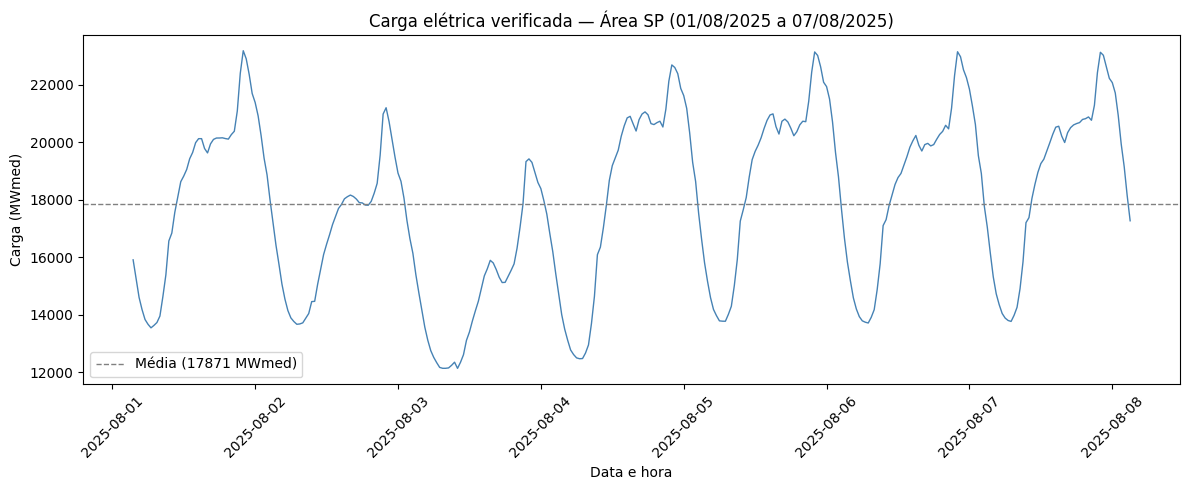

In [20]:
# Gráfico 1 — Carga ao longo do tempo

plt.figure(figsize=(12, 5))
plt.plot(dados_organizados['data_hora'], dados_organizados['carga_mw'], color='steelblue', linewidth=1)
plt.axhline(carga_media, color='gray', linestyle='--', linewidth=1, label=f'Média ({carga_media:.0f} MWmed)')
plt.title('Carga elétrica verificada — Área SP (01/08/2025 a 07/08/2025)')
plt.xlabel('Data e hora')
plt.ylabel('Carga (MWmed)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretação:** *(Complete observando o gráfico.)* Espera-se um padrão diário repetido — carga baixa durante a madrugada, subindo ao longo da manhã, com pico geralmente no início da noite (ponta), e voltando a cair depois. Observe se o padrão se repete de forma semelhante nos 7 dias analisados ou se há algum dia com comportamento fora do padrão.

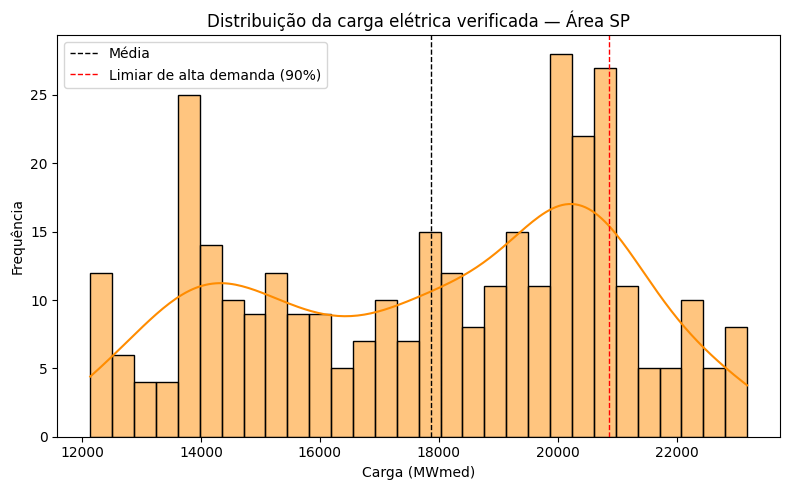

In [21]:
# Gráfico 2 — Distribuição da carga (histograma)

plt.figure(figsize=(8, 5))
sns.histplot(dados_organizados['carga_mw'], bins=30, kde=True, color='darkorange')
plt.axvline(carga_media, color='black', linestyle='--', linewidth=1, label='Média')
plt.axvline(limiar_alta_demanda, color='red', linestyle='--', linewidth=1, label='Limiar de alta demanda (90%)')
plt.title('Distribuição da carga elétrica verificada — Área SP')
plt.xlabel('Carga (MWmed)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretação:** *(Complete observando o gráfico.)* O histograma mostra em quais faixas de carga a maior parte das medições se concentra. Se a distribuição for concentrada próxima à média e com poucas medições próximas ao limiar de alta demanda, isso reforça a conclusão do DESAFIO 4 de que os picos são eventos relativamente raros dentro do período analisado.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [22]:
# DESAFIO 7 — Síntese para o relatório

momento_pico = pico_registro['data_hora'].iloc[0] if not pico_registro.empty else "não identificado"

resumo_resultados = f'''
Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_min:.2f} MWmed
Carga máxima: {carga_max:.2f} MWmed
Carga média: {carga_media:.2f} MWmed
Mediana: {carga_mediana:.2f} MWmed
Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed
Registros de alta demanda: {qtd_alta_demanda} ({pct_alta_demanda:.2f}% do total)
Momento do pico: {momento_pico}
Segundo critério (carga acima da média): {qtd_acima_media} registros ({pct_acima_media:.2f}% do total)
'''

print(resumo_resultados)


Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros de alta demanda: 50 (14.88% do total)
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (carga acima da média): 184 registros (54.76% do total)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [23]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [24]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

**Respostas da equipe:**

1. Como a equipe optou por não utilizar a API do Gemini nesta entrega (etapa marcada como opcional no enunciado), o relatório final abaixo foi escrito diretamente pela equipe, com base nos indicadores e gráficos calculados nas etapas anteriores.
2. Não se aplica, pelo mesmo motivo.
3. Não se aplica, pelo mesmo motivo.
4. Não se aplica — o texto final foi redigido diretamente pela equipe.

## Relatório final

No período de 01/08/2025 a 07/08/2025, foram registradas 336 medições semi-horárias de carga elétrica verificada para a área de São Paulo (SP), obtidas via API pública do ONS.

A carga variou entre um mínimo de 12.139,25 MWmed e um máximo de 23.185,31 MWmed, com média de 17.870,83 MWmed e mediana de 18.199,13 MWmed. A proximidade entre média e mediana indica uma distribuição sem forte assimetria, mas o valor máximo representa um patamar bem acima do comportamento típico do período (cerca de 30% acima da média). O gráfico da série temporal confirma um padrão diário bem definido, com queda de carga durante a madrugada e pico próximo às 22h em cada um dos 7 dias analisados.

Considerando como alta demanda os registros acima de 90% da carga máxima (limiar de 20.866,78 MWmed), foram identificados 50 registros nessa faixa, o que representa 14,88% do total de medições. O pico absoluto de 23.185,31 MWmed ocorreu em 01/08/2025, às 22h00.

Um segundo recorte, considerando a carga acima da média do período (17.870,83 MWmed), resultou em 184 registros (54,76% do total) — mais de três vezes o número de registros de alta demanda, já que este critério é naturalmente menos restritivo.

**Conclusão:** os dados mostram um padrão de carga com variação diária esperada e bastante regular ao longo da semana analisada, com picos de demanda concentrados em uma parcela pequena do período (menos de 15% das medições) e localizados consistentemente no período noturno, próximo às 22h. Os resultados aqui apresentados são observações diretas dos dados obtidos via API do ONS; nenhuma causa para as variações foi inferida, apenas os comportamentos estatísticos observados no recorte de 7 dias analisado.

---

## Entrega

O notebook apresenta:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Este notebook deve ser executado do início ao fim em um ambiente com acesso à internet (recomendado: Google Colab), com todas as células executadas e os resultados visíveis, antes de ser enviado ao repositório.**